# AI와빅데이터경영입문 중간과제

- 학번: 202457-352014
- 이름: 신승엽
- 학과: 첨단공학부 AI전공
- 연락처: 010-4195-1949

---

## seaborn 다이아몬드(diamonds) 데이터 분석

## (1) 데이터 로드하기

In [1]:
!uv pip install seaborn

Audited 1 package in 6ms


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

# 구글 코랩 한글 폰트 설정
import os
if 'COLAB_RELEASE_TAG' in os.environ:
    !apt-get install -y fonts-nanum > /dev/null 2>&1
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
else:
    plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False

# 다이아몬드 데이터 로드
diamonds = sns.load_dataset('diamonds')

# 데이터 확인
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
# 기본 통계량 확인
diamonds.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [4]:
# 데이터 타입 및 결측치 확인
diamonds.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


### 발견한 사실
- diamonds 데이터셋은 53,940개의 행과 10개의 열로 구성되어 있다.
- 수치형 변수 7개(carat, depth, table, price, x, y, z), 범주형 변수 3개(cut, color, clarity)
- 결측치는 없었다.

## (2) 히스토그램(histplot) 그리기

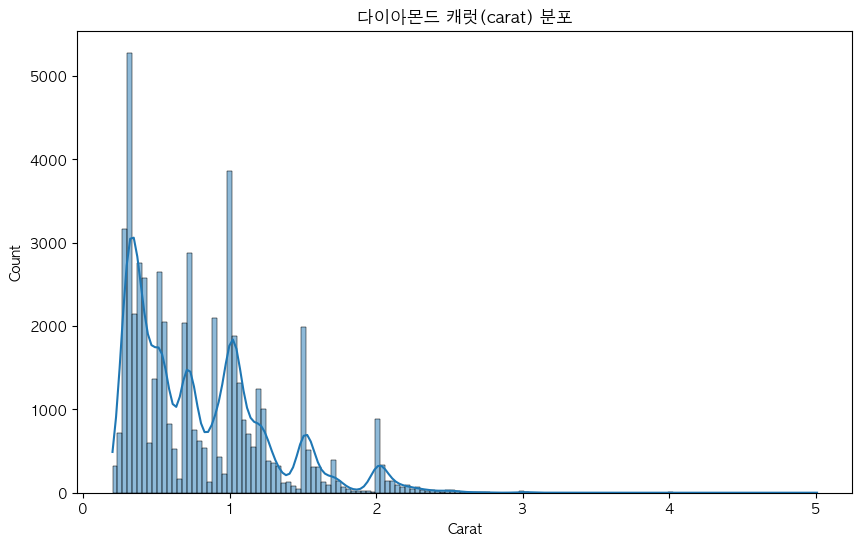

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(data=diamonds, x="carat", kde=True)
plt.title('다이아몬드 캐럿(carat) 분포')
plt.xlabel('Carat')
plt.ylabel('Count')
plt.show()

### 해석
- 캐럿 분포가 오른쪽으로 꼬리가 긴 형태(right-skewed)이다. 대부분 0.2~1.5캐럿 사이에 몰려 있다.
- 0.3캐럿이랑 1.0캐럿 근처에서 봉우리가 생기는데, 아무래도 소비자들이 선호하는 구간이 있는 것 같다.
- 2캐럿 넘어가면 매우 드물다.

## (3) 상자그림(boxplot) 그리기

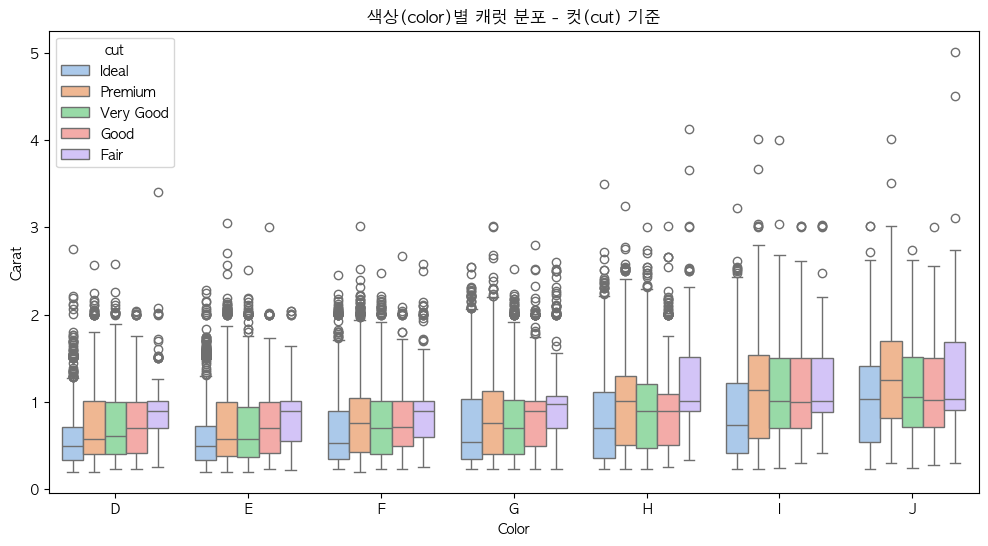

In [6]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="color", y="carat", hue="cut", data=diamonds, palette="pastel")
plt.title('색상(color)별 캐럿 분포 - 컷(cut) 기준')
plt.xlabel('Color')
plt.ylabel('Carat')
plt.show()

### 해석
- color가 D에서 J로 갈수록 캐럿 중앙값이 올라가는 경향이 보인다. 큰 다이아몬드일수록 색이 잘 보여서 낮은 등급으로 분류되는 경우가 많은 듯하다.
- cut별로 보면 Fair 등급이 캐럿이 큰 편이고, Ideal은 작은 쪽에 몰려 있다.
- 이상치가 꽤 많이 보이는데 특히 고캐럿 쪽에서 두드러진다.

## (4) 바이올린그림(violinplot) 그리기

/var/folders/tp/j6lf2w8n6yl5mrg4d8dkcz8m0000gn/T/ipykernel_18225/2061879292.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="cut", y="carat", data=diamonds, palette="pastel")


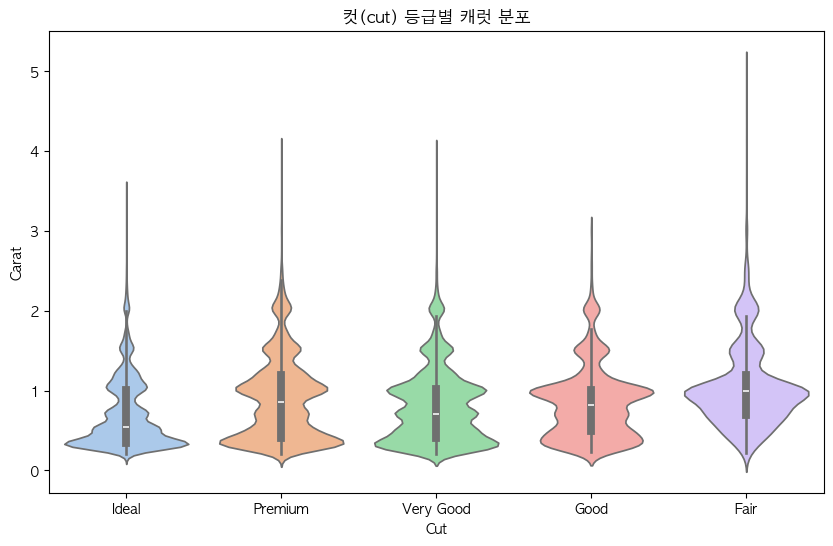

In [7]:
plt.figure(figsize=(10, 6))
sns.violinplot(x="cut", y="carat", data=diamonds, palette="pastel")
plt.title('컷(cut) 등급별 캐럿 분포')
plt.xlabel('Cut')
plt.ylabel('Carat')
plt.show()

### 해석
- Ideal이나 Premium은 바이올린이 아래쪽(낮은 캐럿)에서 넓다. 작은 다이아몬드가 많다는 뜻이다.
- Fair 등급은 분포가 넓고 중앙값도 높은 편인데, 큰 원석은 이상적인 비율로 커팅하기가 어려워서 그런 것 같다.

## (5) 상관계수 히트맵(heatmap) 그리기

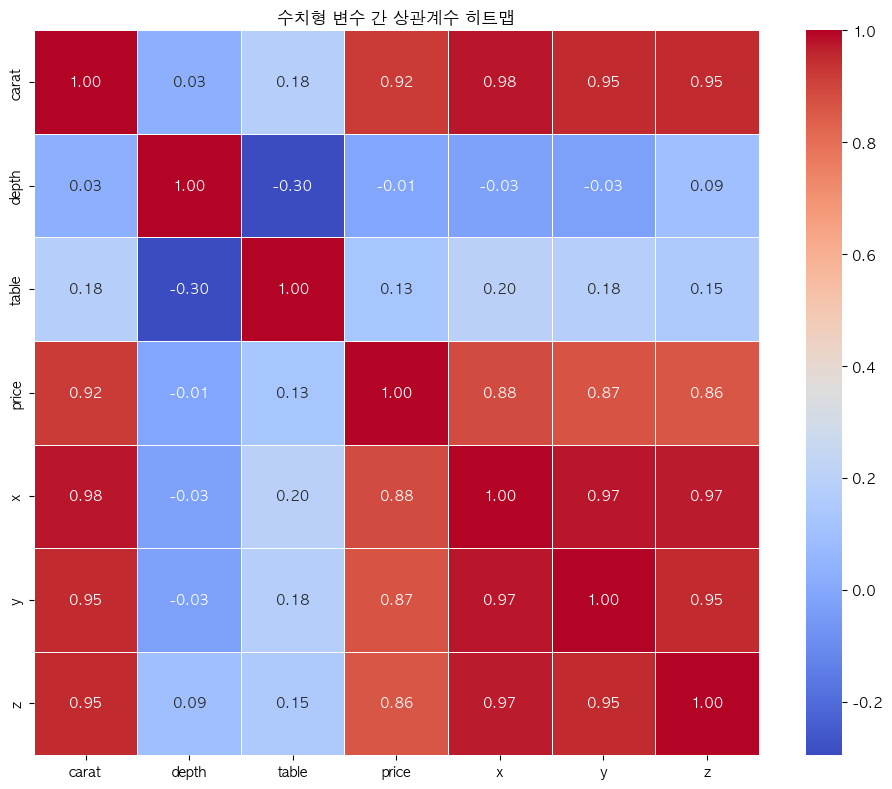

In [8]:
# 숫자형 변수만 추출
diamonds_num = diamonds.select_dtypes(include=['float64', 'int64'])

# 결측치 제거
diamonds_num_dropna = diamonds_num.dropna()

# 상관계수 행렬 계산
corr_matrix = diamonds_num_dropna.corr()

# 히트맵 그리기
plt.figure(figsize=(10, 8))
sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('수치형 변수 간 상관계수 히트맵')
plt.tight_layout()
plt.show()

### 해석
- carat-price 상관계수가 0.92로 가장 높다. 캐럿이 가격을 결정하는 핵심 요인이다.
- x, y, z는 물리적 크기인데 carat, price와도 높은 상관(0.86~0.98)을 보인다. 크면 무겁고 비싸니까 당연한 결과다.
- depth, table은 다른 변수들과 상관이 낮다. 비율 관련 값이라 크기나 가격과 직접 관련이 적은 것 같다.
- x, y, z끼리는 거의 1에 가까운 상관을 보여서, 나중에 회귀분석을 하게 되면 다중공선성을 신경 써야 할 것 같다.

---

## 수행 과정에서 발견한 사실

1. 데이터가 53,940개로 꽤 많은데 결측치가 하나도 없어서 별도 전처리 없이 바로 분석에 들어갈 수 있었다.

2. 캐럿이 가격과 상관계수 0.92로 가장 높았다. 다이아몬드 가격은 결국 무게가 제일 중요한 요인인 것 같다.

3. cut 등급이 좋다고(Ideal) 캐럿이 큰 게 아니었다. 오히려 Fair 등급에서 캐럿이 큰 다이아몬드가 많이 보였는데, 큰 원석을 깎을 때 완벽한 비율을 맞추기가 어렵기 때문인 것 같다.

4. x, y, z 변수가 서로 거의 같은 값을 가지고 있어서 셋 다 넣으면 다중공선성 문제가 생길 수 있겠다는 생각이 들었다.

## 분석 결과에 대한 해석

시각화를 통해 가장 먼저 눈에 띈 건 캐럿과 가격의 관계였다. 히트맵에서 상관계수가 0.92로 나왔고, 실제로 히스토그램에서도 대부분의 다이아몬드가 소형(0.2~1.5캐럿)인 것을 보면 큰 다이아몬드가 그만큼 희소하고 비싸다는 걸 알 수 있다.

boxplot이랑 violinplot에서 재밌었던 건 cut 등급과 캐럿의 관계다. 보통 좋은 커팅 등급이면 비싸고 클 거라고 생각할 수 있는데, 실제로는 Ideal 등급 다이아몬드가 캐럿이 작은 쪽에 집중되어 있었다. 큰 원석을 완벽하게 커팅하기가 더 어려운 거라 그런 것 같다.

히스토그램에서 0.3, 1.0캐럿 같은 특정 구간에 봉우리가 생기는 것도 흥미로웠다. 소비자가 "1캐럿짜리"처럼 라운드 넘버를 선호하다 보니 해당 구간에 제품이 몰리는 것 같다.

---

## 참고문헌

1. seaborn 공식 문서 - Diamonds dataset: https://seaborn.pydata.org/generated/seaborn.load_dataset.html
2. seaborn 공식 문서 - histplot: https://seaborn.pydata.org/generated/seaborn.histplot.html
3. seaborn 공식 문서 - boxplot: https://seaborn.pydata.org/generated/seaborn.boxplot.html
4. seaborn 공식 문서 - violinplot: https://seaborn.pydata.org/generated/seaborn.violinplot.html
5. seaborn 공식 문서 - heatmap: https://seaborn.pydata.org/generated/seaborn.heatmap.html
6. Wickham, H. (2016). ggplot2: Elegant Graphics for Data Analysis. Springer-Verlag New York. (diamonds 데이터 원출처)